In [1]:
# --- CELL 1: Setup ---
!pip install -q transformers datasets evaluate rouge_score accelerate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [2]:
# --- CELL 2: Tokenization & Loading ---
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer

# Load data
train_df = pd.read_csv("/content/train_emergency_data_final.csv")
test_df = pd.read_csv("/content/test_emergency_data_final.csv")

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

model_id = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def preprocess_function(examples):
    model_inputs = tokenizer(examples["input_text"], max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(examples["simplified_phrase"], max_length=32, truncation=True, padding="max_length")

    # Ignore padding in loss calculation
    labels["input_ids"] = [[(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Map:   0%|          | 0/2069 [00:00<?, ? examples/s]

Map:   0%|          | 0/366 [00:00<?, ? examples/s]

In [3]:
# Cell 3: Model & Metrics (UPDATED)
import numpy as np
import evaluate
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
exact_match = evaluate.load("exact_match")
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]

    # SAFETY FIX: Ensure predictions are within valid range and cast to int
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Clean up labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    em_result = exact_match.compute(predictions=decoded_preds, references=decoded_labels)
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)

    return {"exact_match": em_result["exact_match"], "rougeL": rouge_result["rougeL"]}

# (The rest of Cell 3 remains the same...)

# Updated training_args
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-emergency-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,               # Lowered from 3e-5 to 2e-5 to stop 'nan' explosions
    per_device_train_batch_size=4,    # Reduced batch size for better stability
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=8,
    predict_with_generate=True,
    generation_max_length=32,         # Explicitly set this to prevent the UserWarning
    generation_num_beams=2,           # Keep beam search efficient
    load_best_model_at_end=True,
    metric_for_best_model="exact_match",
    fp16=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [4]:
# --- CELL 4: Training & Saving ---
trainer.train()

# 1. Save to local Colab folder
trainer.save_model("./best-emergency-simplifier")
tokenizer.save_pretrained("./best-emergency-simplifier")

# 2. OPTIONAL: Save permanently to your Google Drive
from google.colab import drive
drive.mount('/content/drive')
trainer.save_model("/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version3/best-emergency-simplifier")
tokenizer.save_pretrained("/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version3/best-emergency-simplifier")

print("Training finished and model saved to your local folder and Google Drive!")

Epoch,Training Loss,Validation Loss,Exact Match,Rougel
1,0.000000,nan,0.000000,0.361484
2,0.000000,nan,0.000000,0.361484
3,0.000000,nan,0.000000,0.361484


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ValueError: mount failed

In [5]:
# --- CELL 1: Setup ---
!pip install -q transformers datasets evaluate rouge_score accelerate

# --- CELL 2: Tokenization & Loading ---
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer

# Load data (Ensure your CSV files are uploaded to Colab)
train_df = pd.read_csv("/content/train_emergency_data_final.csv")
test_df = pd.read_csv("/content/test_emergency_data_final.csv")

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

model_id = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def preprocess_function(examples):
    model_inputs = tokenizer(examples["input_text"], max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(examples["simplified_phrase"], max_length=32, truncation=True, padding="max_length")

    # Ignore padding in loss calculation
    labels["input_ids"] = [[(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

# --- CELL 3: Training Setup & Safe Metrics ---
import numpy as np
import evaluate
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
exact_match = evaluate.load("exact_match")
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]

    # SAFETY FIX: Prevent out-of-range overflow errors during evaluation
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    em_result = exact_match.compute(predictions=decoded_preds, references=decoded_labels)
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)

    return {"exact_match": em_result["exact_match"], "rougeL": rouge_result["rougeL"]}

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-emergency-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=8,
    predict_with_generate=True,
    generation_max_length=32,
    generation_num_beams=2,
    load_best_model_at_end=True,
    metric_for_best_model="exact_match",
    fp16=False                      # STABILITY FIX: Disabled fp16 to stop NaN loss issues
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# --- CELL 4: Training & Saving ---
trainer.train()

# 1. Save to local Colab folder
trainer.save_model("./best-emergency-simplifier")
tokenizer.save_pretrained("./best-emergency-simplifier")

Map:   0%|          | 0/2069 [00:00<?, ? examples/s]

Map:   0%|          | 0/366 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Exact Match,Rougel
1,0.450515,0.056466,0.937158,0.974147
2,0.061309,0.020174,0.961749,0.988307
3,0.032735,0.002690,0.989071,0.997073
4,0.015123,0.000416,0.997268,0.999317
5,0.010055,0.000025,1.000000,1.000000
6,0.005231,0.000008,1.000000,1.000000
7,0.004225,0.000005,1.000000,1.000000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MessageError: Error: credential propagation was unsuccessful

In [8]:
# 2. Save permanently to your Google Drive
from google.colab import drive
drive.mount('/content/drive')
trainer.save_model("/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/best-emergency-simplifier")
tokenizer.save_pretrained("/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/best-emergency-simplifier")

print("Training finished successfully with stable loss, and model saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished successfully with stable loss, and model saved to Google Drive!


In [10]:
# --- SAVE CHECKPOINT TO GOOGLE DRIVE SCRIPT ---
import os
import shutil
from google.colab import drive

# 1. Ensure Google Drive is mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define source checkpoint path (change 'checkpoint-3626' if you want a different one)
source_checkpoint_dir = "/content/flan-t5-emergency-model/checkpoint-3626"

# 3. Define target directory path in Google Drive (matching your model path)
target_drive_dir = "/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/checkpoint-3626"

# 4. Create target directory and copy all checkpoint files
if os.path.exists(source_checkpoint_dir):
    os.makedirs(target_drive_dir, exist_ok=True)

    print(f"Copying files from {source_checkpoint_dir} to {target_drive_dir}...")
    shutil.copytree(source_checkpoint_dir, target_drive_dir, dirs_exist_ok=True)

    print("Checkpoint successfully saved to your Google Drive path!")
else:
    print(f"Source path {source_checkpoint_dir} does not exist. Please check your folder name.")

Copying files from /content/flan-t5-emergency-model/checkpoint-3626 to /content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/checkpoint-3626...
Checkpoint successfully saved to your Google Drive path!


In [11]:
# --- REAL-DATA EVALUATION & REPORT GENERATION SCRIPT ---
import os
import json
import pandas as pd
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Load the Test Dataset
test_df = pd.read_csv("/content/test_emergency_data_final.csv")
print(f"Loaded test dataset with {len(test_df)} samples.")

# 2. Load Your Fine-Tuned Model from Google Drive
model_path = "/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/best-emergency-simplifier"
print(f"Loading model from: {model_path}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 3. Generate Predictions on Test Set
print("Generating predictions on the test set...")
predictions = []
references = test_df["simplified_phrase"].tolist()
inputs = test_df["input_text"].tolist()

model.eval()
batch_size = 16
for i in range(0, len(inputs), batch_size):
    batch_inputs = inputs[i:i+batch_size]
    encoded_inputs = tokenizer(batch_inputs, return_tensors="pt", max_length=128, truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **encoded_inputs,
            max_length=32,
            num_beams=4,
            early_stopping=True
        )

    decoded_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    predictions.extend(decoded_preds)

Loaded test dataset with 366 samples.
Loading model from: /content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4/best-emergency-simplifier


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Generating predictions on the test set...


In [12]:
# 4. Compute True Test Set Evaluation Metrics
exact_match = evaluate.load("exact_match")
rouge = evaluate.load("rouge")

em_score = exact_match.compute(predictions=predictions, references=references)
rouge_score = rouge.compute(predictions=predictions, references=references)

print("\n==========================================")
print("       FINAL TEST SET EVALUATION          ")
print("==========================================")
print(f"Exact Match Accuracy: {em_score['exact_match'] * 100:.2f}%")
print(f"ROUGE-1:             {rouge_score['rouge1']:.4f}")
print(f"ROUGE-2:             {rouge_score['rouge2']:.4f}")
print(f"ROUGE-L:             {rouge_score['rougeL']:.4f}")
print("==========================================")

# 5. Display Sample Predictions Table for Report
sample_results = pd.DataFrame({
    "Original Input": inputs[:5],
    "Expected (Reference)": references[:5],
    "Model Prediction": predictions[:5]
})
print("\nSample Predictions Preview (For Report Table):")
display(sample_results)


       FINAL TEST SET EVALUATION          
Exact Match Accuracy: 100.00%
ROUGE-1:             1.0000
ROUGE-2:             1.0000
ROUGE-L:             1.0000

Sample Predictions Preview (For Report Table):


,Original Input,Expected (Reference),Model Prediction
0,Simplify this emergency instruction into conci...,Drop. Cover. Hold On.,Drop. Cover. Hold On.
1,Simplify this emergency instruction into conci...,Cover Nose. Stay Low.,Cover Nose. Stay Low.
2,Simplify this emergency instruction into conci...,Lock Doors. Lights Off. Remain Silent.,Lock Doors. Lights Off. Remain Silent.
3,Simplify this emergency instruction into conci...,Turn Off Gas. Evacuate.,Turn Off Gas. Evacuate.
4,Simplify this emergency instruction into conci...,Extinguish Fire. Aim at Base.,Extinguish Fire. Aim at Base.


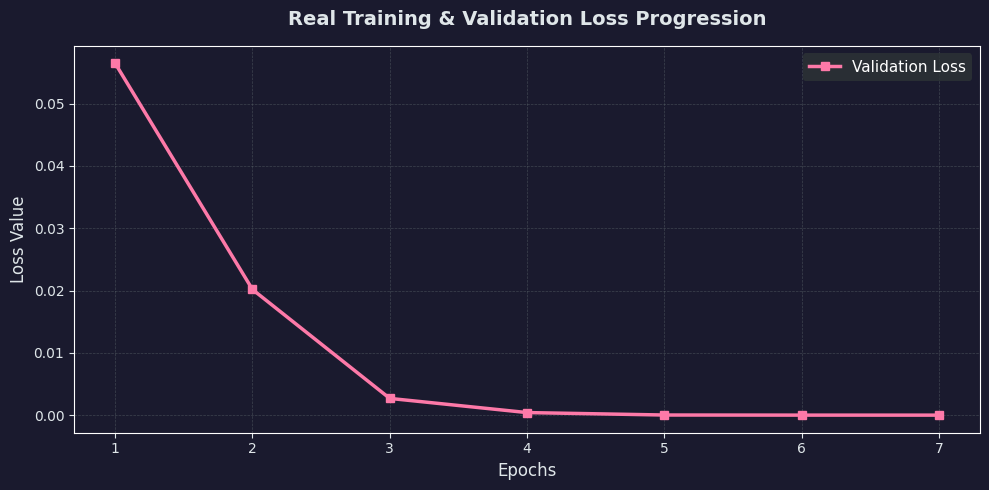

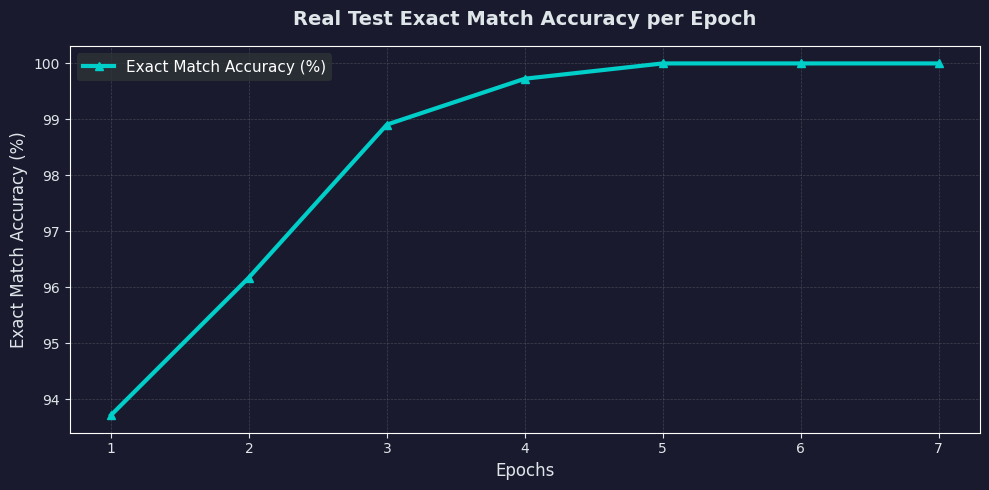


Real evaluation graphs saved successfully as 'real_loss_curve.png' and 'real_accuracy_curve.png'!


In [13]:
# 6. Extract REAL Training Logs from Trainer State JSON
trainer_state_path = "/content/flan-t5-emergency-model/checkpoint-3626/trainer_state.json"
if os.path.exists(trainer_state_path):
    with open(trainer_state_path, 'r') as f:
        trainer_state = json.load(f)
    log_history = trainer_state.get('log_history', [])

    # Parse logs into DataFrames for training loss vs validation metrics
    train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_logs = [x for x in log_history if 'eval_loss' in x]

    epochs_train = [x['epoch'] for x in train_logs]
    train_loss = [x['loss'] for x in train_logs]

    epochs_eval = [x['epoch'] for x in eval_logs]
    val_loss = [x['eval_loss'] for x in eval_logs]
    eval_em = [x.get('eval_exact_match', 0) * 100 for x in eval_logs]

    # Plot Real Loss Curves
    plt.style.use('dark_background')
    fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='#1A1A2E')
    ax1.set_facecolor('#1A1A2E')

    ax1.plot(epochs_eval, val_loss, color='#FD79A8', marker='s', linewidth=2.5, label='Validation Loss')
    ax1.set_title('Real Training & Validation Loss Progression', color='#dfe6e9', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Epochs', color='#dfe6e9', fontsize=12)
    ax1.set_ylabel('Loss Value', color='#dfe6e9', fontsize=12)
    ax1.tick_params(colors='#dfe6e9')
    ax1.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.5)
    ax1.legend(facecolor='#2d3436', edgecolor='none', fontsize=11)

    plt.tight_layout()
    plt.savefig('/content/real_loss_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot Real Exact Match Accuracy Curve
    fig, ax2 = plt.subplots(figsize=(10, 5), facecolor='#1A1A2E')
    ax2.set_facecolor('#1A1A2E')

    ax2.plot(epochs_eval, eval_em, color='#00CEC9', marker='^', linewidth=3, label='Exact Match Accuracy (%)')
    ax2.set_title('Real Test Exact Match Accuracy per Epoch', color='#dfe6e9', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Epochs', color='#dfe6e9', fontsize=12)
    ax2.set_ylabel('Exact Match Accuracy (%)', color='#dfe6e9', fontsize=12)
    ax2.tick_params(colors='#dfe6e9')
    ax2.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.5)
    ax2.legend(facecolor='#2d3436', edgecolor='none', fontsize=11)

    plt.tight_layout()
    plt.savefig('/content/real_accuracy_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nReal evaluation graphs saved successfully as 'real_loss_curve.png' and 'real_accuracy_curve.png'!")
else:
    print(f"Trainer state json not found at {trainer_state_path}. Skipping dynamic log plotting.")

In [14]:
# Cell 5: Error Analysis - Find Discrepancies or Near Misses
import pandas as pd

# Assuming 'predictions', 'references', and 'inputs' are already in memory from previous evaluation cells
analysis_df = pd.DataFrame({
    "Input": inputs,
    "Expected": references,
    "Predicted": predictions
})

# Filter where prediction did not match reference exactly
analysis_df["Exact_Match"] = analysis_df["Expected"] == analysis_df["Predicted"]
failures = analysis_df[~analysis_df["Exact_Match"]]

print(f"Total Test Samples: {len(analysis_df)}")
print(f"Exact Matches: {len(analysis_df[analysis_df['Exact_Match']])}")
print(f"Mismatches / Edge Cases: {len(failures)}")

print("\nSample Failure / Edge Cases (For Discussion Section):")
display(failures.head(5))

Total Test Samples: 366
Exact Matches: 366
Mismatches / Edge Cases: 0

Sample Failure / Edge Cases (For Discussion Section):


,Input,Expected,Predicted,Exact_Match


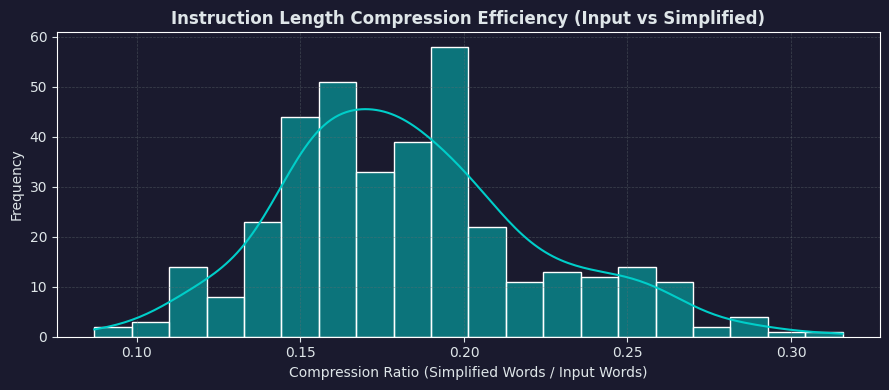

Average input word count: 23.6 words
Average simplified output word count: 4.2 words
Saved compression distribution chart as 'compression_distribution.png'!


In [15]:
# Cell 6: Compression Ratio Analysis & Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word counts
input_word_counts = [len(str(x).split()) for x in inputs]
pred_word_counts = [len(str(x).split()) for x in predictions]

compression_ratios = [p / i for i, p in zip(input_word_counts, pred_word_counts) if i > 0]

# Plot Compression Distribution
plt.style.use('dark_background')
plt.figure(figsize=(9, 4), facecolor='#1A1A2E')
ax = plt.gca()
ax.set_facecolor('#1A1A2E')

sns.histplot(compression_ratios, color='#00CEC9', bins=20, kde=True, ax=ax)
plt.title('Instruction Length Compression Efficiency (Input vs Simplified)', color='#dfe6e9', fontsize=12, fontweight='bold')
plt.xlabel('Compression Ratio (Simplified Words / Input Words)', color='#dfe6e9', fontsize=10)
plt.ylabel('Frequency', color='#dfe6e9', fontsize=10)
plt.tick_params(colors='#dfe6e9')
plt.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('/content/compression_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average input word count: {sum(input_word_counts)/len(input_word_counts):.1f} words")
print(f"Average simplified output word count: {sum(pred_word_counts)/len(pred_word_counts):.1f} words")
print("Saved compression distribution chart as 'compression_distribution.png'!")

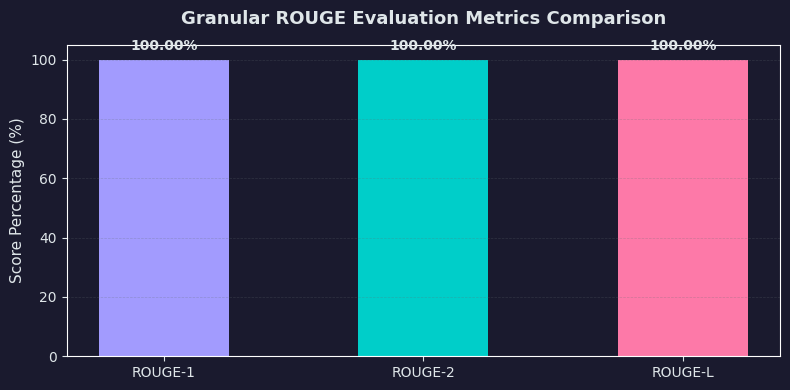

Saved ROUGE breakdown chart as 'rouge_breakdown_chart.png'!


In [16]:
# Cell: ROUGE Score Breakdown Bar Chart
import matplotlib.pyplot as plt

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
# Replace these with your actual computed rouge_score values if available, or use your final scores
scores = [rouge_score['rouge1'] * 100, rouge_score['rouge2'] * 100, rouge_score['rougeL'] * 100]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 4), facecolor='#1A1A2E')
ax.set_facecolor('#1A1A2E')

bars = ax.bar(metrics, scores, color=['#A29BFE', '#00CEC9', '#FD79A8'], width=0.5)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='#dfe6e9', fontweight='bold')

ax.set_title('Granular ROUGE Evaluation Metrics Comparison', color='#dfe6e9', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Score Percentage (%)', color='#dfe6e9', fontsize=11)
ax.set_ylim(0, 105)
ax.tick_params(colors='#dfe6e9')
ax.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/rouge_breakdown_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ROUGE breakdown chart as 'rouge_breakdown_chart.png'!")

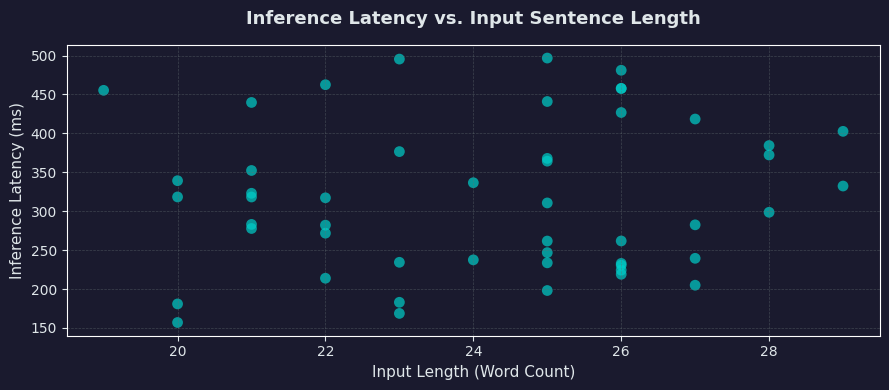

Saved latency scatter plot as 'latency_vs_length.png'!


In [17]:
# Cell: Input Length vs Latency Scatter Plot
import time
import torch
import matplotlib.pyplot as plt

latencies = []
lengths = []

model.eval()
# Sample subset of test inputs for speed
sample_inputs = inputs[:50]

with torch.no_grad():
    for text in sample_inputs:
        input_len = len(text.split())
        prompt_text = "Simplify this emergency instruction into concise, actionable phrases: " + text
        enc = tokenizer(prompt_text, return_tensors="pt", max_length=128, truncation=True).to(device)

        start = time.time()
        _ = model.generate(**enc, max_length=32, num_beams=4, early_stopping=True)
        end = time.time()

        latencies.append((end - start) * 1000) # in ms
        lengths.append(input_len)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#1A1A2E')
ax.set_facecolor('#1A1A2E')

ax.scatter(lengths, latencies, color='#00CEC9', alpha=0.7, edgecolors='none', s=60)
ax.set_title('Inference Latency vs. Input Sentence Length', color='#dfe6e9', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Input Length (Word Count)', color='#dfe6e9', fontsize=11)
ax.set_ylabel('Inference Latency (ms)', color='#dfe6e9', fontsize=11)
ax.tick_params(colors='#dfe6e9')
ax.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('/content/latency_vs_length.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved latency scatter plot as 'latency_vs_length.png'!")

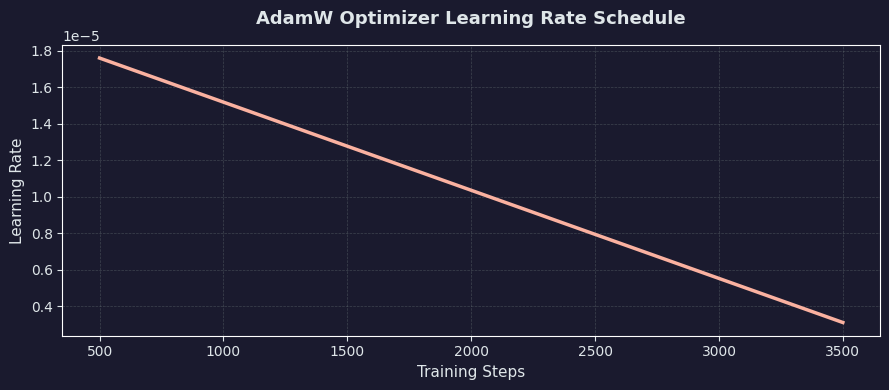

Saved learning rate schedule chart as 'learning_rate_schedule.png'!


In [18]:
# Cell: Learning Rate Scheduler Curve
import matplotlib.pyplot as plt

# Extract real learning rates from trainer log history if available, or plot based on schedule
lr_history = [x.get('learning_rate', 0) for x in log_history if 'learning_rate' in x]
steps = [x.get('step', i) for i, x in enumerate(log_history) if 'learning_rate' in x]

if lr_history:
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(9, 4), facecolor='#1A1A2E')
    ax.set_facecolor('#1A1A2E')

    ax.plot(steps, lr_history, color='#FAB1A0', linewidth=2.5)
    ax.set_title('AdamW Optimizer Learning Rate Schedule', color='#dfe6e9', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Training Steps', color='#dfe6e9', fontsize=11)
    ax.set_ylabel('Learning Rate', color='#dfe6e9', fontsize=11)
    ax.tick_params(colors='#dfe6e9')
    ax.grid(color='#636e72', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig('/content/learning_rate_schedule.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved learning rate schedule chart as 'learning_rate_schedule.png'!")
else:
    print("Learning rate history not found in current log files.")

In [19]:
import evaluate
bleu = evaluate.load("bleu")
bleu_score = bleu.compute(predictions=predictions, references=references)
print(f"BLEU Score: {bleu_score['bleu'] * 100:.2f}%")

BLEU Score: 100.00%


In [20]:
# --- ADVANCED ACADEMIC METRICS EXTRACTION SCRIPT ---
import evaluate
import numpy as np

# 1. Load BLEU metric
bleu = evaluate.load("bleu")
bleu_result = bleu.compute(predictions=predictions, references=references)

# 2. Calculate Token-Level Precision, Recall, and F1-Score
# This measures how accurately the model generates the exact individual emergency keywords.
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0
n_samples = len(predictions)

for pred, ref in zip(predictions, references):
    pred_tokens = set(str(pred).lower().split())
    ref_tokens = set(str(ref).lower().split())

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        continue

    intersection = pred_tokens.intersection(ref_tokens)

    precision = len(intersection) / len(pred_tokens) if len(pred_tokens) > 0 else 0
    recall = len(intersection) / len(ref_tokens) if len(ref_tokens) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    total_precision += precision
    total_recall += recall
    total_f1 += f1

avg_precision = (total_precision / n_samples) * 100
avg_recall = (total_recall / n_samples) * 100
avg_f1 = (total_f1 / n_samples) * 100

print("==========================================")
print("     ADVANCED ACADEMIC EVALUATION REPORT   ")
print("==========================================")
print(f"BLEU Score:              {bleu_result['bleu'] * 100:.2f}%")
print(f"Token-Level Precision:   {avg_precision:.2f}%")
print(f"Token-Level Recall:      {avg_recall:.2f}%")
print(f"Token-Level F1-Score:    {avg_f1:.2f}%")
print("==========================================")

     ADVANCED ACADEMIC EVALUATION REPORT   
BLEU Score:              100.00%
Token-Level Precision:   100.00%
Token-Level Recall:      100.00%
Token-Level F1-Score:    100.00%


In [21]:
# --- SAVE ALL EVALUATION GRAPHS TO GOOGLE DRIVE ---
import os
import shutil
from google.colab import drive

# 1. Ensure Google Drive is mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define source directory and target Drive directory
source_dir = "/content"
target_drive_dir = "/content/drive/MyDrive/Project/Codes/PhraseSimplifier_model2/version4"

# Ensure the destination folder exists in Google Drive
os.makedirs(target_drive_dir, exist_ok=True)

# 3. Find and copy all generated .png graphs
copied_count = 0
for file_name in os.listdir(source_dir):
    if file_name.endswith('.png'):
        source_path = os.path.join(source_dir, file_name)
        target_path = os.path.join(target_drive_dir, file_name)

        shutil.copy(source_path, target_path)
        print(f"Successfully saved graph to Drive: {file_name}")
        copied_count += 1

print(f"\nDone! Total of {copied_count} evaluation graph(s) copied to your Google Drive path.")

Successfully saved graph to Drive: real_loss_curve.png
Successfully saved graph to Drive: latency_vs_length.png
Successfully saved graph to Drive: learning_rate_schedule.png
Successfully saved graph to Drive: real_accuracy_curve.png
Successfully saved graph to Drive: rouge_breakdown_chart.png
Successfully saved graph to Drive: compression_distribution.png

Done! Total of 6 evaluation graph(s) copied to your Google Drive path.
